# M4 Learnnavi 
### Team DataBridge (Jean Frégeville, Mathis Richard and Paul Guillon)

## Research Question: How can we cluster Learnnavi users based on their engagement?

In [1]:
import warnings
warnings.filterwarnings("ignore")

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam

from sklearn.preprocessing import MinMaxScaler, StandardScaler
from sklearn.metrics import mean_squared_error, silhouette_score
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.manifold import TSNE
from sklearn.neighbors import kneighbors_graph
from scipy.sparse.csgraph import laplacian
from scipy.sparse.linalg import eigsh
from sklearn.decomposition import PCA
from sklearn.mixture import GaussianMixture

import plotly.io as pio
import plotly.graph_objects as go

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

I0000 00:00:1777578694.402552   10452 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1777578694.424449   10452 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1777578695.067417   10452 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1777578709.333089   10452 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONE

In [2]:
DATA_DIR = 'data'

users = pd.read_csv('{}/users.csv.gz'.format(DATA_DIR))
events = pd.read_csv('{}/events.csv.gz'.format(DATA_DIR))
transactions = pd.read_csv('{}/transactions.csv.gz'.format(DATA_DIR))

---

## First let's add a week column like in the Milestone 2

In [3]:
# Convert strings to datetime objects
events['event_date'] = pd.to_datetime(events['event_date'])
transactions['commit_time'] = pd.to_datetime(transactions['commit_time'])

# Create the 'week' column (same idea than in the M2)
events['week'] = events['event_date'].dt.isocalendar().week
transactions['week'] = transactions['commit_time'].dt.isocalendar().week

---

## 1. Behavioral engagement

In [4]:
# Frequency: Number of unique sessions per week
num_sessions = events.groupby(['user_id', 'week'])['session_id'].nunique().rename('num_sessions')

# Intensity: Total number of events per week
total_events = events.groupby(['user_id', 'week']).size().rename('event_density')

# Continuity: Number of active days per week
events['event_day'] = events['event_date'].dt.date
active_days = events.groupby(['user_id', 'week'])['event_day'].nunique().rename('active_days_per_week')

# Intensity: Events per active day
effort_intensity = (total_events / active_days).rename('effort_per_active_day')

# Regularity: Inverse of session delta standard deviation
events = events.sort_values(['user_id', 'event_date'])
events['session_start'] = events.groupby(['user_id', 'session_id'])['event_date'].transform('min')
session_timestamps = events[['user_id', 'week', 'session_id', 'session_start']].drop_duplicates()
session_timestamps['delta_session'] = session_timestamps.groupby(['user_id'])['session_start'].diff().dt.total_seconds()

# Regularity = 1 / std(delta) -> Higher means more regular intervals
regularity = 1 / session_timestamps.groupby(['user_id', 'week'])['delta_session'].std().fillna(0)
regularity = regularity.replace([float('inf')], 1).rename('usage_regularity')

# Control Variables
user_controls = users[['user_id', 'class_level']].copy()

# Merging everything into Behavioral DataFrame
behavioral_df = events[['user_id', 'week']].drop_duplicates()
behavioral_df = behavioral_df.merge(num_sessions, on=['user_id', 'week'], how='left')
behavioral_df = behavioral_df.merge(total_events, on=['user_id', 'week'], how='left')
behavioral_df = behavioral_df.merge(active_days, on=['user_id', 'week'], how='left')
behavioral_df = behavioral_df.merge(effort_intensity, on=['user_id', 'week'], how='left')
behavioral_df = behavioral_df.merge(regularity, on=['user_id', 'week'], how='left')
behavioral_df = behavioral_df.merge(user_controls, on='user_id', how='left')

behavioral_df = behavioral_df.fillna(0)

In [5]:
behavioral_df

,user_id,week,num_sessions,event_density,active_days_per_week,effort_per_active_day,usage_regularity,class_level
0,387604,20,0,1,1,1.0,1.000000,0
1,387604,21,0,1,1,1.0,1.000000,0
2,387604,25,1,14,2,7.0,1.000000,0
3,387604,26,2,25,1,25.0,1.000000,0
4,387604,31,0,12,1,12.0,1.000000,0
...,...,...,...,...,...,...,...,...
91731,431999,5,4,125,1,125.0,0.003034,Gymnasium - 1. Jahr (GYM1)
91732,432001,5,1,60,1,60.0,1.000000,Gymnasium - 1. Jahr (GYM1)
91733,432014,5,2,80,1,80.0,1.000000,Gymnasium - 1. Jahr (GYM1)
91734,432016,5,2,72,1,72.0,1.000000,Gymnasium - 1. Jahr (GYM1)


---

## 2. Cognitive engagement

### We'll begin by creating a variable allowing us to define the number of time the student tried a task before succeeding


In [6]:
# Chronological sort
df = transactions.sort_values(['user_id', 'document_id', 'commit_time'])
#print(df)

df_clean = df.dropna(subset=['evaluation'])

# Success indicator (1 if correct, 0 otherwise)
df_clean['is_success'] = (df_clean['evaluation'] == "CORRECT").astype(int)

# Calculate the rank of the attempt per (user, document)
df_clean['attempt_rank'] = df_clean.groupby(['user_id', 'document_id']).cumcount()

# Find the rank of the first success
first_success = df_clean[df_clean['is_success'] == 1].groupby(['user_id', 'document_id'])['attempt_rank'].min().reset_index()
first_success.columns = ['user_id', 'document_id', 'attempts_before_success']
first_success

,user_id,document_id,attempts_before_success
0,387604,111K3PY6sbr8ac1mRGpse1,0
1,387604,1AttLqCSVAG9SSyOa2kKjy,0
2,387604,1Cy0Q7U9KDa0LPXbFgGWq,0
3,387604,1GpdRHVuQlh94iFfQmNWCm,0
4,387604,1OsXDzU2Vaa96BnfNEQ7KT,0
...,...,...,...
565772,432020,1o3LL10odKY5PO6p1JUO3z,0
565773,432020,3D1CxLYFxg05BXUT05iSkX,0
565774,432020,4XxkqhWKjkJ9tneNsk55k4,0
565775,432020,7WaFr9SoOQE7kqtMcXKLZe,0


In [7]:
# Keeping only interesting cases
persistence_cases = first_success[first_success['attempts_before_success'] > 0]
persistence_cases

,user_id,document_id,attempts_before_success
156,387605,0Ihkl0CyzoWSjDm5F,1
157,387605,11OglEqMVbR88jMtKSpp1o,3
167,387605,38u4Hk3rufR7Rf3q0YVuvu,3
171,387605,3mk59PSa1xQ8FOcjsbO6fV,1
203,387605,8HecQ7yDlSG9aiBhsntSGe,1
...,...,...,...
565411,431873,2T7rLoYqDGAaZi3adwZ8vF,1
565509,431896,6PTVZbR39oO5YhYpDh09Wk,1
565513,431896,8Sa5Z92pJ59RzVApjSnlu,1
565514,431896,XoT2lIiIi89AocWKlpqnZ,1


In [8]:
# Test to see if the last cell works well
print("Top 10 of hardest tasks :")
first_success.sort_values('attempts_before_success', ascending=False).head(10)

Top 10 of hardest tasks :


,user_id,document_id,attempts_before_success
3695,387711,9yHL1E2Ap2q8dO63Fe7HWX,148
3427,387711,2DkAp7YKckR9uPGFz393km,148
3436,387711,2O9MAmD1bG77VuXY5KCSU2,148
3573,387711,6Ossa8oxu1c8pUa0tnBcjk,147
3656,387711,93WzP3qF6fI9CJLgDPvxTn,51
3744,387711,jJ90eWETJF631tnISdQLS,51
3716,387711,aCrt7mXfgO360CFZJGN2QL,50
3725,387711,aNUkBMAD3zp9ORO9sNuNrq,50
3419,387711,1sdAox3Ua1B9Te29v6mrNX,48
3458,387711,33I5a1DkVb861c11UhgRhY,39


In [9]:
# Average number of attempts before success per student
struggling_students = first_success.groupby('user_id')['attempts_before_success'].mean().reset_index()

# Sort by the highest average (descending)
struggling_students = struggling_students.sort_values('attempts_before_success', ascending=False)

struggling_students.columns = ['user_id', 'avg_attempts_before_success']

print("Top 10 of struggling students (based on average failures per task):")
struggling_students.head(10)

Top 10 of struggling students (based on average failures per task):


,user_id,avg_attempts_before_success
27,387711,5.841962
18708,428180,2.642857
16317,418122,2.500000
15350,415755,2.363636
19152,429454,2.130435
3530,395763,2.125000
4386,396859,2.000000
9992,405646,2.000000
2329,394208,2.000000
12870,410960,2.000000


### Then let's create the whole dataframe

In [10]:
# Success Rate
transactions['score'] = transactions['evaluation'].map({'CORRECT': 1, 'PARTIAL': 0.5}).fillna(0)
perf = transactions.groupby(['user_id', 'week'])['score'].agg(['mean', 'count'])
success_rate = perf['mean'].rename('avg_success_rate')

# Response Latency (= time taken to answer)
transactions['duration'] = (pd.to_datetime(transactions['commit_time']) - pd.to_datetime(transactions['start_time'])).dt.total_seconds()
avg_latency = transactions.groupby(['user_id', 'week'])['duration'].mean().rename('avg_response_latency (in sec)')

# Persistence (using the pre-calculated first_success variable in previous cells)
persistence = first_success.groupby('user_id')['attempts_before_success'].mean().rename('persistence_score')

# Time Invested for Success (Time spent on correct answers)
transactions['duration'] = (pd.to_datetime(transactions['commit_time']) - pd.to_datetime(transactions['start_time'])).dt.total_seconds()
time_to_success = transactions[transactions['evaluation'] == 'CORRECT'].groupby(['user_id', 'week'])['duration'].mean().rename('avg_time_to_success (in sec)')

# Learning Efficiency (Mean evaluation score)
transactions['eval_score'] = transactions['evaluation'].map({'CORRECT': 1, 'PARTIAL': 0.5, 'WRONG': 0}).fillna(0)
learning_efficiency = transactions.groupby(['user_id', 'week'])['eval_score'].mean().rename('learning_efficiency')

# Local Perseverance (= attempts on failed topics)
topic_failures = transactions[transactions['evaluation'] != 'CORRECT'].groupby(['user_id', 'week', 'topic_id']).size().reset_index(name='failed_attempts')
local_perseverance = topic_failures.groupby(['user_id', 'week'])['failed_attempts'].mean().rename('avg_perseverance_per_topic')


cognitive_df = transactions[['user_id', 'week']].drop_duplicates()
cognitive_df = cognitive_df.merge(success_rate, on=['user_id', 'week'], how='left')
cognitive_df = cognitive_df.merge(avg_latency, on=['user_id', 'week'], how='left')
cognitive_df = cognitive_df.merge(persistence, on='user_id', how='left')
cognitive_df = cognitive_df.merge(time_to_success, on=['user_id', 'week'], how='left')
cognitive_df = cognitive_df.merge(learning_efficiency, on=['user_id', 'week'], how='left')
cognitive_df = cognitive_df.merge(local_perseverance, on=['user_id', 'week'], how='left')

cognitive_df = cognitive_df.fillna(0)

In [11]:
cognitive_df

,user_id,week,avg_success_rate,avg_response_latency (in sec),persistence_score,avg_time_to_success (in sec),learning_efficiency,avg_perseverance_per_topic
0,393211,20,0.454545,158.239182,0.000000,197.621667,0.454545,0.000000
1,393213,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
2,388032,20,0.258065,43.278613,0.000000,29.807000,0.258065,9.666667
3,390142,20,1.000000,103.422000,0.000000,103.422000,1.000000,0.000000
4,390137,23,0.833333,605565.877000,0.181818,47.585000,0.833333,1.000000
...,...,...,...,...,...,...,...,...
88514,423254,5,0.000000,5.953714,0.222222,0.000000,0.000000,3.500000
88515,408050,5,0.552632,25.018947,0.000000,29.525143,0.552632,4.000000
88516,431424,0,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
88517,408053,5,0.500000,65.207350,0.000000,24.554250,0.500000,8.000000


---

## 3. Emotional engagement

In [12]:
# Session Acceptance vs Refusal
accepted = events[events['session_accepted'] == 1].groupby(['user_id', 'week']).size().rename('sessions_accepted')
refused = events[events['session_accepted'] == 0].groupby(['user_id', 'week']).size().rename('sessions_refused')

# Voluntary usage (Outside school hours: before 8am, after 5pm, or weekends)
events['is_voluntary'] = (events['event_date'].dt.hour < 8) | (events['event_date'].dt.hour > 17) | (events['event_date'].dt.weekday >= 5)
voluntary_acts = events[events['is_voluntary'] == True].groupby(['user_id', 'week']).size().rename('out_of_school_activity')



# We take previous variables and analyse them comparing to more global ones

# System Adhesion (Ratio of accepted sessions)
adhesion = events.groupby(['user_id', 'week'])['session_accepted'].mean().rename('system_adhesion_ratio')

# "Intrinsic" Motivation (Ratio of out-of-school usage)
total_acts = events.groupby(['user_id', 'week']).size().rename("total_acts")
intrinsic_motivation = (voluntary_acts / total_acts).fillna(0).rename('intrinsic_motivation_ratio')

# Exploratory Curiosity (View / Click ratio)
views = events[events['event_type'] == 'view'].groupby(['user_id', 'week']).size()
clicks = events[events['event_type'] == 'click'].groupby(['user_id', 'week']).size()
curiosity_ratio = (views / clicks).fillna(0).rename('exploratory_curiosity')



emotional_df = events[['user_id', 'week']].drop_duplicates()
emotional_df = emotional_df.merge(accepted, on=['user_id', 'week'], how='left')
emotional_df = emotional_df.merge(refused, on=['user_id', 'week'], how='left')
emotional_df = emotional_df.merge(voluntary_acts, on=['user_id', 'week'], how='left')
emotional_df = emotional_df.merge(total_acts, on=['user_id', 'week'], how='left')
emotional_df = emotional_df.merge(intrinsic_motivation, on=['user_id', 'week'], how='left')
emotional_df = emotional_df.merge(adhesion, on=['user_id', 'week'], how='left')
emotional_df = emotional_df.merge(curiosity_ratio, on=['user_id', 'week'], how='left')

emotional_df = emotional_df.fillna(0)

In [13]:
emotional_df 

,user_id,week,sessions_accepted,sessions_refused,out_of_school_activity,total_acts,intrinsic_motivation_ratio,system_adhesion_ratio,exploratory_curiosity
0,387604,20,0.0,0.0,1.0,1,1.0,0.0,0.0
1,387604,21,0.0,0.0,0.0,1,0.0,0.0,0.0
2,387604,25,3.0,0.0,0.0,14,0.0,1.0,0.0
3,387604,26,11.0,0.0,0.0,25,0.0,1.0,0.0
4,387604,31,0.0,0.0,0.0,12,0.0,0.0,0.0
...,...,...,...,...,...,...,...,...,...
91731,431999,5,0.0,0.0,0.0,125,0.0,0.0,0.0
91732,432001,5,0.0,0.0,0.0,60,0.0,0.0,0.0
91733,432014,5,19.0,0.0,0.0,80,0.0,1.0,0.0
91734,432016,5,0.0,0.0,0.0,72,0.0,0.0,0.0


---

## Clustering

### Spectral Clustering

In [14]:
# 1. Aggregate metrics by user_id to create a "Global Profile"
student_profiles = behavioral_df.groupby('user_id').agg({
    'num_sessions': 'mean',
    'event_density': 'mean',
    'active_days_per_week': 'mean',
    'usage_regularity': 'mean'
}).merge(
    cognitive_df.groupby('user_id').agg({
        'avg_success_rate': 'mean',
        'learning_efficiency': 'mean',
        'persistence_score': 'first' 
    }), on='user_id'
).merge(
    emotional_df.groupby('user_id').agg({
        'intrinsic_motivation_ratio': 'mean',
        'system_adhesion_ratio': 'mean'
    }), on='user_id'
)

# 2. Scale the data
scaler = StandardScaler()
scaled_features = scaler.fit_transform(student_profiles)

In [15]:
def plot_spectral_k_selection(
    X,
    k_range=range(2, 11),
    n_neighbors=10,
    affinity="nearest_neighbors",
    random_state=42
):
    silhouette_scores = []

    # --- Silhouette scores ---
    for k in k_range:
        clustering = SpectralClustering(
            n_clusters=k,
            affinity=affinity,
            n_neighbors=n_neighbors if affinity == "nearest_neighbors" else None,
            assign_labels="kmeans",
            random_state=random_state
        )

        labels = clustering.fit_predict(X)
        score = silhouette_score(X, labels)
        silhouette_scores.append(score)

    # --- Eigengap ---
    clusters = len(list(k_range))
    n_eigenvals = clusters * 2

    A = kneighbors_graph(
        X,
        n_neighbors=n_neighbors,
        mode="connectivity",
        include_self=True
    )

    A = 0.5 * (A + A.T)

    L = laplacian(A, normed=True)

    eigenvals = eigsh(
        L,
        k=n_eigenvals,
        which="SM",
        return_eigenvectors=False
    )

    eigenvals_sorted = np.sort(eigenvals)

    plt.figure(figsize=(7, 4))
    plt.scatter(
        range(1, len(eigenvals_sorted) + 1),
        eigenvals_sorted
    )
    plt.xlabel("Eigenvalue index")
    plt.ylabel("Eigenvalue")
    plt.title("Sorted Laplacian eigenvalues")
    plt.xticks(range(1, len(eigenvals_sorted) + 1))
    plt.grid(True)
    plt.show()

    # --- Plot silhouette ---
    plt.figure(figsize=(7, 4))
    plt.plot(list(k_range), silhouette_scores, marker="o")
    plt.xlabel("Number of clusters k")
    plt.ylabel("Silhouette score")
    plt.title("Silhouette score vs k")
    plt.grid(True)
    plt.show()

    return {
        "k": list(k_range),
        "silhouette": silhouette_scores,
        "eigenvalues": eigenvals_sorted
    }

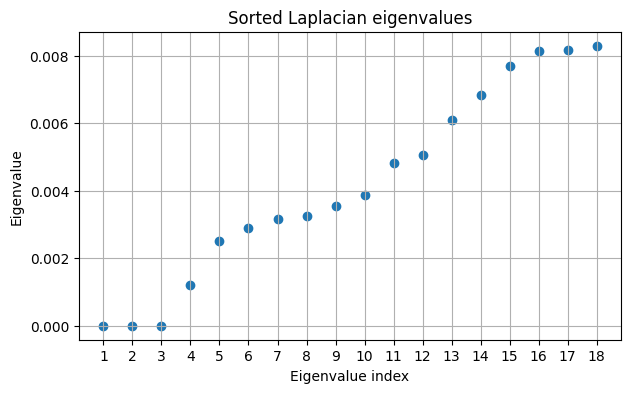

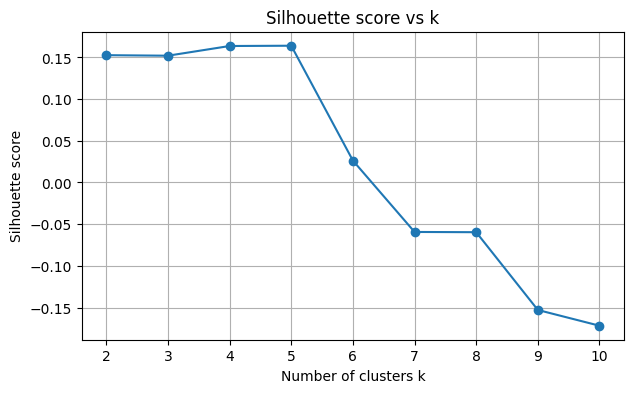

{'k': [2, 3, 4, 5, 6, 7, 8, 9, 10],
 'silhouette': [0.1526878466519813,
  0.15205887296474055,
  0.16368971711595,
  0.1640302903690869,
  0.02627858277335437,
  -0.05935878279034498,
  -0.05964999791524214,
  -0.15293751846524198,
  -0.17182448049730892],
 'eigenvalues': array([-3.05178637e-16, -1.44726854e-16, -3.42005599e-18,  1.22190088e-03,
         2.50680203e-03,  2.89037354e-03,  3.15215518e-03,  3.24156062e-03,
         3.54326648e-03,  3.87431773e-03,  4.81284305e-03,  5.05922344e-03,
         6.09639555e-03,  6.84174782e-03,  7.71342035e-03,  8.15103294e-03,
         8.17042659e-03,  8.30214143e-03])}

In [16]:
plot_spectral_k_selection(scaled_features)

These plots make us choose K=4 for the number of clusters.

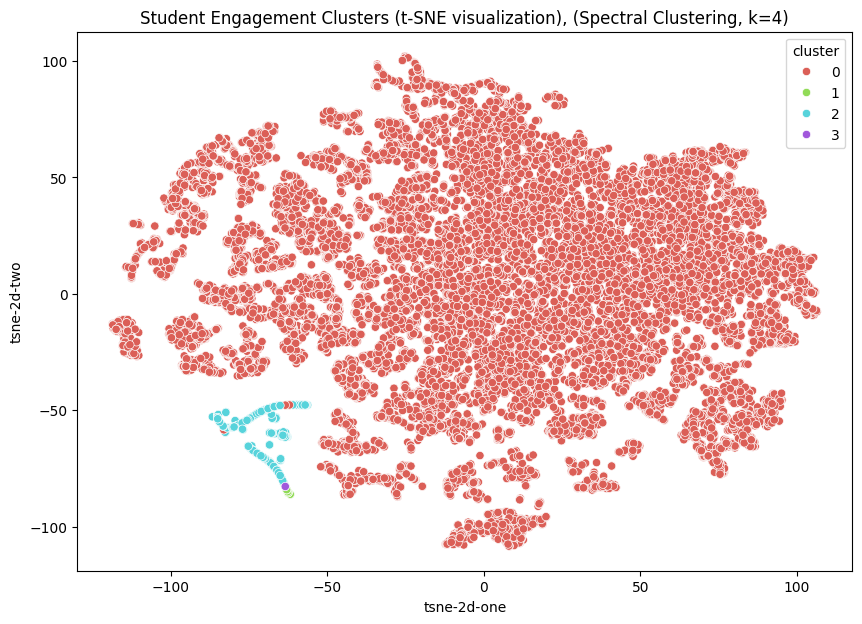

In [17]:
#Clustering using Spectral clustering and adding a visualization through t-SNE method
# Apply Spectral clustering  (We chose K=4 based on the above plots)
clustering = SpectralClustering(
            n_clusters=4,
            affinity="nearest_neighbors",
            n_neighbors=10,
            assign_labels="kmeans",
            random_state=42
        )
student_profiles['cluster'] = clustering.fit_predict(scaled_features)
# Reduce dimensions for visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(scaled_features)

student_profiles['tsne-2d-one'] = tsne_results[:,0]
student_profiles['tsne-2d-two'] = tsne_results[:,1]

plt.figure(figsize=(10,7))
sns.scatterplot(x="tsne-2d-one", y="tsne-2d-two", hue="cluster", 
                palette=sns.color_palette("hls", 4), data=student_profiles, legend="full")
plt.title('Student Engagement Clusters (t-SNE visualization), (Spectral Clustering, k=4)')
plt.show()

Components retained: 7
Total Explained Variance: 98.46%


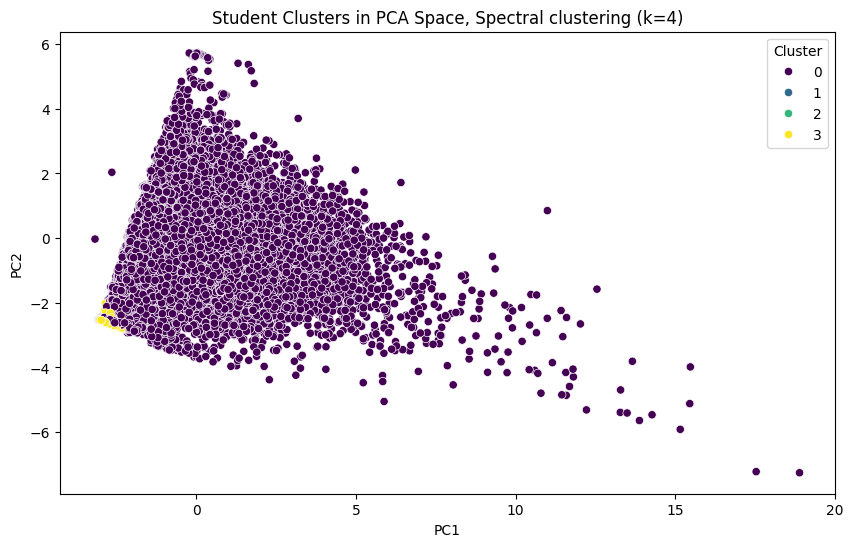

In [18]:
# We aim to keep enough components to explain a high variance (e.g., 95%) 
# or reduce to 2-3 for direct visualization.
pca = PCA(n_components=0.95) 
pca_data = pca.fit_transform(scaled_features)

# 2. Run K-Means (k=4)
clustering = SpectralClustering(
            n_clusters=4,
            affinity="nearest_neighbors",
            n_neighbors=10,
            assign_labels="kmeans",
            random_state=42
        )
clusters = clustering.fit_predict(pca_data)

# 3. Add cluster labels back to the original profile dataframe
student_profiles['cluster'] = clusters

# 4. Check Explained Variance
print(f"Components retained: {pca.n_components_}")
print(f"Total Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

# Create a plot-friendly DataFrame
pca_df = pd.DataFrame(
    data=pca_data[:, :2], 
    columns=['PC1', 'PC2']
)
pca_df['Cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='viridis', data=pca_df)
plt.title('Student Clusters in PCA Space, Spectral clustering (k=4)')
plt.show()

The fact that nearly all points belong to cluster 0, and that the other clusters have only a few points suggests that Spectral Clustering might not be the best approach in our context. We try K-Means Clustering next.

### K-Means Clustering

In [19]:
K = range(2, 11)

inertia = []
silhouette = []
bic = []

for k in K:
    # KMeans
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(scaled_features)

    # inertia 
    inertia.append(km.inertia_)
    # silhouette score
    silhouette.append(silhouette_score(scaled_features, labels))

    # Gaussian Mixture for BIC
    gmm = GaussianMixture(
        n_components=k,
        covariance_type="full",
        random_state=42
    )
    gmm.fit(scaled_features)
    bic.append(gmm.bic(scaled_features))

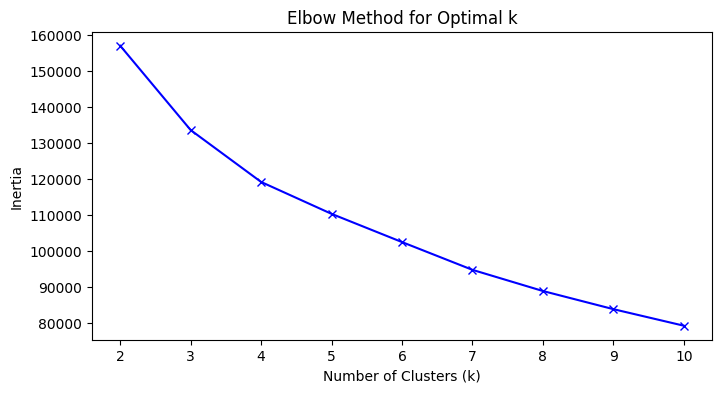

In [20]:
plt.figure(figsize=(8, 4))
plt.plot(K, inertia, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method for Optimal k')
plt.show()

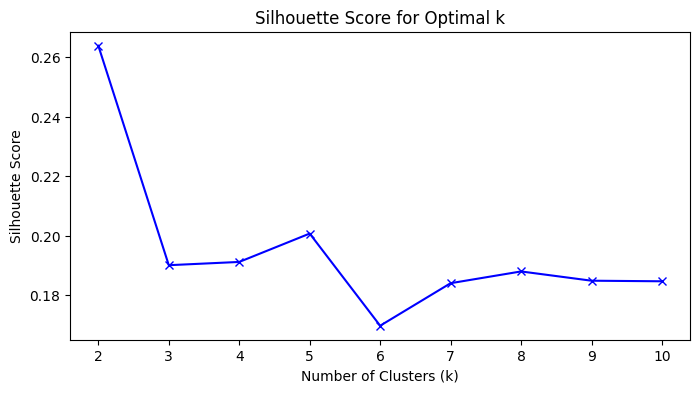

In [21]:
plt.figure(figsize=(8, 4))
plt.plot(K, silhouette, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('Silhouette Score')
plt.title('Silhouette Score for Optimal k')
plt.show()

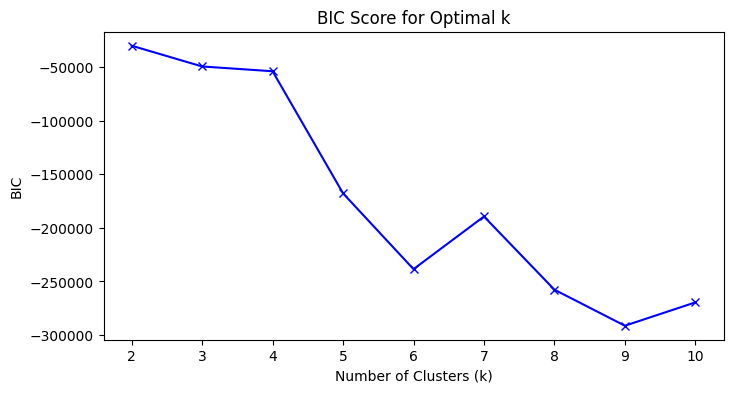

In [22]:
plt.figure(figsize=(8, 4))
plt.plot(K, bic, 'bx-')
plt.xlabel('Number of Clusters (k)')
plt.ylabel('BIC')
plt.title('BIC Score for Optimal k')
plt.show()

Based on the three above plots, we choose K=4.

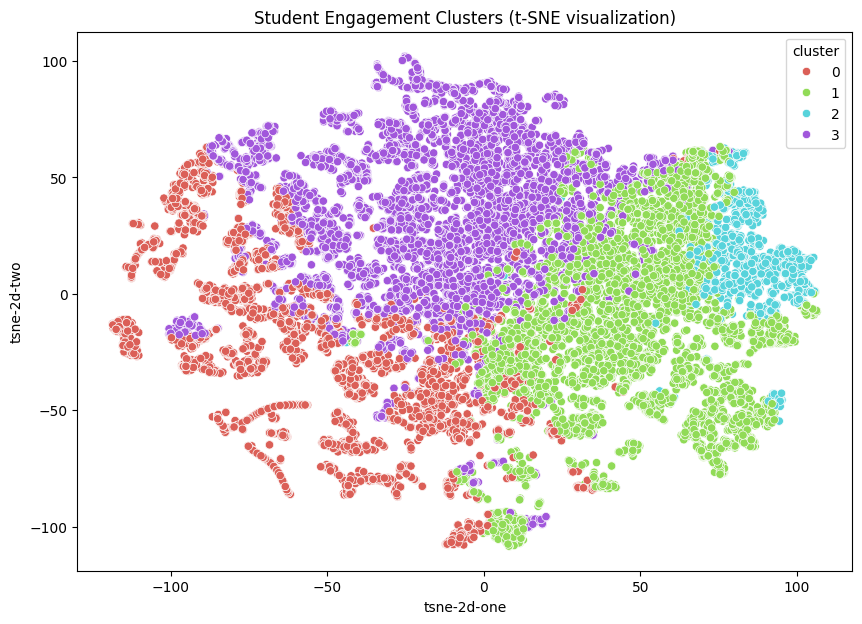

In [23]:
#Clustering using K-means and adding a visualization through t-SNE method
# Apply K-Means with K=4
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
student_profiles['cluster'] = kmeans.fit_predict(scaled_features)
# Reduce dimensions for visualization
tsne = TSNE(n_components=2, perplexity=30, random_state=42)
tsne_results = tsne.fit_transform(scaled_features)

student_profiles['tsne-2d-one'] = tsne_results[:,0]
student_profiles['tsne-2d-two'] = tsne_results[:,1]

plt.figure(figsize=(10,7))
sns.scatterplot(x="tsne-2d-one", y="tsne-2d-two", hue="cluster", 
                palette=sns.color_palette("hls", 4), data=student_profiles, legend="full")
plt.title('Student Engagement Clusters (t-SNE visualization)')
plt.show()

In [24]:
# We aim to keep enough components to explain a high variance (e.g., 95%) 
# or reduce to 2-3 for direct visualization.
pca = PCA(n_components=0.95) 
pca_data = pca.fit_transform(scaled_features)

# 2. Run K-Means (k=4)
kmeans = KMeans(n_clusters=4, init='k-means++', random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_data)

# 3. Add cluster labels back to the original profile dataframe
student_profiles['cluster'] = clusters

# 4. Check Explained Variance
print(f"Components retained: {pca.n_components_}")
print(f"Total Explained Variance: {pca.explained_variance_ratio_.sum():.2%}")

Components retained: 7
Total Explained Variance: 98.46%


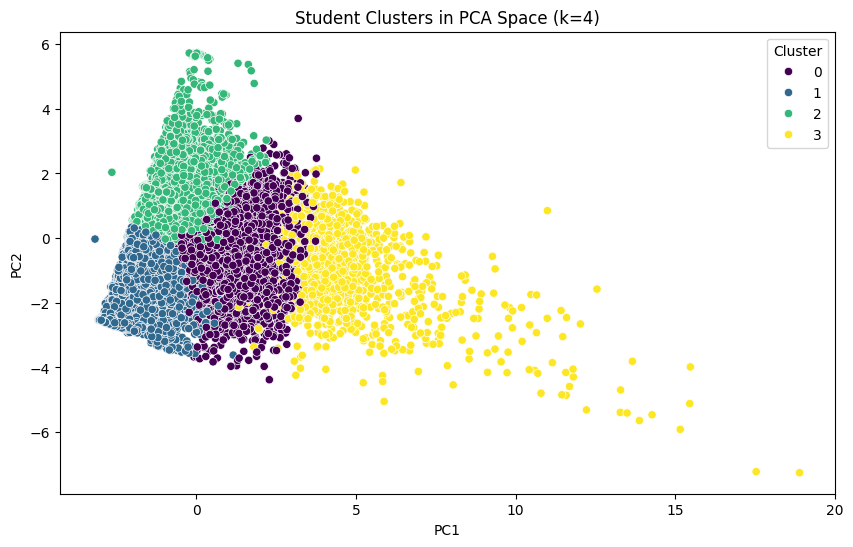

In [25]:
# Create a plot-friendly DataFrame
pca_df = pd.DataFrame(
    data=pca_data[:, :2], 
    columns=['PC1', 'PC2']
)
pca_df['Cluster'] = clusters

plt.figure(figsize=(10, 6))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', palette='viridis', data=pca_df)
plt.title('Student Clusters in PCA Space (k=4)')
plt.show()

### Results & Analysis

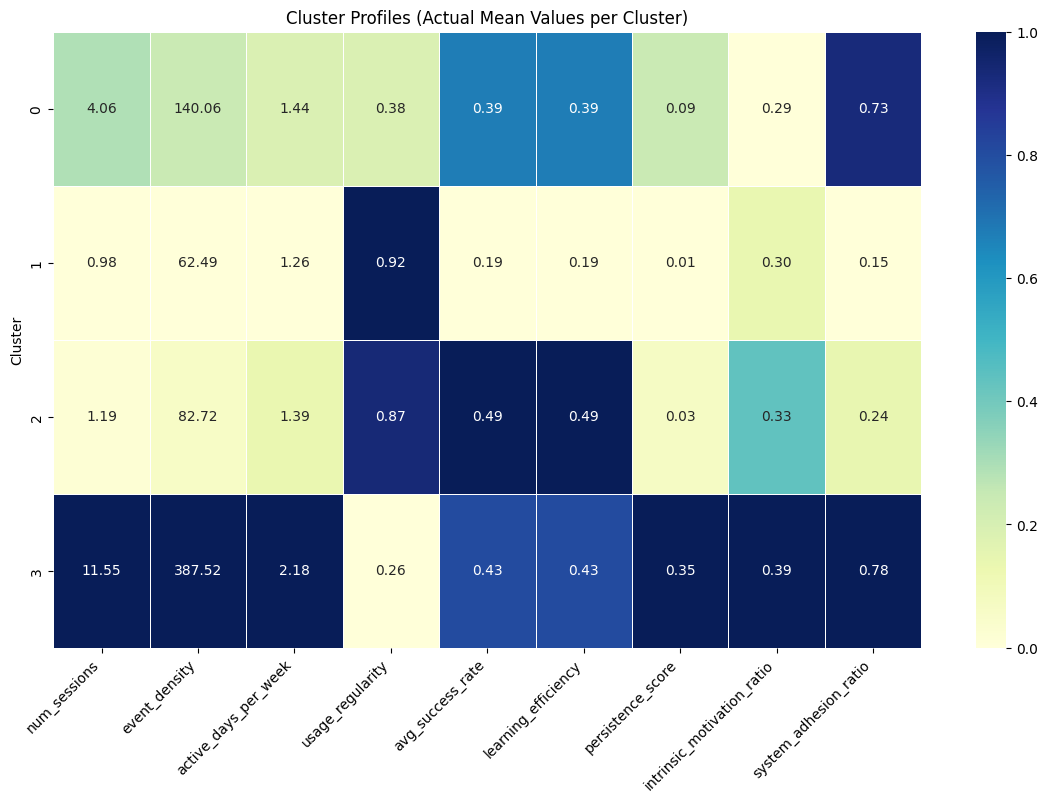

In [26]:
# 1. Calculate cluster centroids (mean of original unscaled features per cluster)
# Dropping TSNE columns if they exist from the previous cell
cols_to_drop = ['tsne-2d-one', 'tsne-2d-two']
profile_metrics = student_profiles.drop(columns=[c for c in cols_to_drop if c in student_profiles.columns])

cluster_profiles = profile_metrics.groupby('cluster').mean()

# 2. Visualize using a Heatmap 
scaler_viz = MinMaxScaler()
cluster_profiles_scaled = pd.DataFrame(
    scaler_viz.fit_transform(cluster_profiles), 
    columns=cluster_profiles.columns, 
    index=cluster_profiles.index
)

plt.figure(figsize=(14, 8))
sns.heatmap(cluster_profiles_scaled, annot=cluster_profiles, cmap="YlGnBu", fmt=".2f", linewidths=.5)
plt.title("Cluster Profiles (Actual Mean Values per Cluster)")
plt.ylabel("Cluster")
plt.xticks(rotation=45, ha='right')
plt.show()

In [27]:
cols_to_exclude = ['cluster', 'tsne-2d-one', 'tsne-2d-two']
metrics_only = student_profiles.drop(columns=[c for c in cols_to_exclude if c in student_profiles.columns])
cluster_means = metrics_only.groupby(student_profiles['cluster']).mean()

In [28]:
persona_mapping = {}

# Split clusters into "High Success" and "Low Success" halves based on avg_success_rate
success_ranked = cluster_means['avg_success_rate'].sort_values(ascending=False).index.tolist()
high_success_clusters = success_ranked[:2]
low_success_clusters = success_ranked[2:]

# Differentiate the High Success clusters by usage_regularity
if cluster_means.loc[high_success_clusters[0], 'usage_regularity'] > cluster_means.loc[high_success_clusters[1], 'usage_regularity']:
    persona_mapping[high_success_clusters[0]] = "Self-Regulated Achievers"
    persona_mapping[high_success_clusters[1]] = "Efficient Minimalists (Crammers)"
else:
    persona_mapping[high_success_clusters[1]] = "Self-Regulated Achievers"
    persona_mapping[high_success_clusters[0]] = "Efficient Minimalists (Crammers)"

# Differentiate the Low Success clusters by effort (event_density)
if cluster_means.loc[low_success_clusters[0], 'event_density'] > cluster_means.loc[low_success_clusters[1], 'event_density']:
    persona_mapping[low_success_clusters[0]] = "Struggling Hard-Workers"
    persona_mapping[low_success_clusters[1]] = "Ghost / At-Risk"
else:
    persona_mapping[low_success_clusters[1]] = "Struggling Hard-Workers"
    persona_mapping[low_success_clusters[0]] = "Ghost / At-Risk"

# 3. Apply the labels to the original dataframe
student_profiles['Persona'] = student_profiles['cluster'].map(persona_mapping)

# 4. Generate a Stakeholder-Ready Summary
total_students = len(student_profiles)
persona_counts = student_profiles['Persona'].value_counts()
persona_percentages = (persona_counts / total_students) * 100

for persona, count in persona_counts.items():
    pct = persona_percentages[persona]
    print(f"{persona}: {count:,} students ({pct:.1f}%)")

# Display a clean, rounded dataframe of the defining traits for reporting
display_cols = ['avg_success_rate', 'usage_regularity', 'event_density', 'active_days_per_week']
summary_df = cluster_means[display_cols].copy()
summary_df.index = summary_df.index.map(persona_mapping)
summary_df = summary_df.round(2)
display(summary_df)

Self-Regulated Achievers: 8,281 students (36.9%)
Struggling Hard-Workers: 7,180 students (32.0%)
Ghost / At-Risk: 5,729 students (25.5%)
Efficient Minimalists (Crammers): 1,280 students (5.7%)


,avg_success_rate,usage_regularity,event_density,active_days_per_week
cluster,,,,
Struggling Hard-Workers,0.39,0.38,140.06,1.44
Ghost / At-Risk,0.19,0.92,62.49,1.26
Self-Regulated Achievers,0.49,0.87,82.72,1.39
Efficient Minimalists (Crammers),0.43,0.26,387.52,2.18


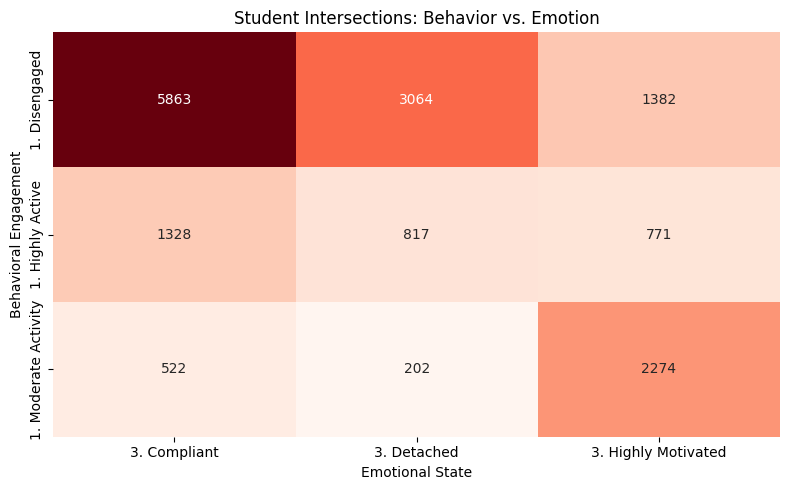

In [29]:
behav_cols = ['num_sessions', 'event_density', 'active_days_per_week', 'usage_regularity']
cog_cols = ['avg_success_rate', 'learning_efficiency', 'persistence_score']
emo_cols = ['intrinsic_motivation_ratio', 'system_adhesion_ratio']

behav_scaled = scaler.fit_transform(student_profiles[behav_cols])
behav_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(behav_scaled)
student_profiles['behav_cluster'] = behav_kmeans.labels_

cog_scaled = scaler.fit_transform(student_profiles[cog_cols])
cog_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(cog_scaled)
student_profiles['cog_cluster'] = cog_kmeans.labels_

emo_scaled = scaler.fit_transform(student_profiles[emo_cols])
emo_kmeans = KMeans(n_clusters=4, random_state=42, n_init=10).fit(emo_scaled)
student_profiles['emo_cluster'] = emo_kmeans.labels_

# Rank Behavioral by active days
behav_means = student_profiles.groupby('behav_cluster')[behav_cols].mean()
behav_rank = behav_means['active_days_per_week'].sort_values().index
behav_map = {behav_rank[0]: "1. Disengaged", behav_rank[1]: "1. Moderate Activity", behav_rank[2]: "1. Highly Active"}

# Rank Cognitive by success rate
cog_means = student_profiles.groupby('cog_cluster')[cog_cols].mean()
cog_rank = cog_means['avg_success_rate'].sort_values().index
cog_map = {cog_rank[0]: "2. Struggling", cog_rank[1]: "2. Average Performers", cog_rank[2]: "2. High Performers"}

# Rank Emotional by system adhesion
emo_means = student_profiles.groupby('emo_cluster')[emo_cols].mean()
emo_rank = emo_means['system_adhesion_ratio'].sort_values().index
emo_map = {emo_rank[0]: "3. Detached", emo_rank[1]: "3. Compliant", emo_rank[2]: "3. Highly Motivated"}

student_profiles['Behavior'] = student_profiles['behav_cluster'].map(behav_map)
student_profiles['Cognition'] = student_profiles['cog_cluster'].map(cog_map)
student_profiles['Emotion'] = student_profiles['emo_cluster'].map(emo_map)


# How do Behavior and Emotion intersect?
plt.figure(figsize=(8, 5))
behav_vs_emo = pd.crosstab(student_profiles['Behavior'], student_profiles['Emotion'])
sns.heatmap(behav_vs_emo, annot=True, fmt='d', cmap='Reds', cbar=False)
plt.title("Student Intersections: Behavior vs. Emotion")
plt.ylabel("Behavioral Engagement")
plt.xlabel("Emotional State")
plt.tight_layout()
plt.show()

In [30]:
print("Top 5 student trajectories")
super_personas = student_profiles.groupby(['Behavior', 'Cognition', 'Emotion']).size().reset_index(name='Student Count')
super_personas = super_personas.sort_values(by='Student Count', ascending=False)
display(super_personas.head(5))

Top 5 student trajectories


,Behavior,Cognition,Emotion,Student Count
0,1. Disengaged,2. Average Performers,3. Compliant,2680
1,1. Disengaged,2. Average Performers,3. Detached,1406
6,1. Disengaged,2. Struggling,3. Compliant,1020
20,1. Moderate Activity,2. Average Performers,3. Highly Motivated,987
2,1. Disengaged,2. Average Performers,3. Highly Motivated,681


In [31]:
pio.renderers.default = "iframe"
all_nodes = list(behav_map.values()) + list(cog_map.values()) + list(emo_map.values())
node_dict = {name: i for i, name in enumerate(all_nodes)}

sources = []
targets = []
values = []

# Behavior -> Cognition
flow1 = student_profiles.groupby(['Behavior', 'Cognition']).size().reset_index(name='count')
for _, row in flow1.iterrows():
    sources.append(node_dict[row['Behavior']])
    targets.append(node_dict[row['Cognition']])
    values.append(row['count'])

#Cognition -> Emotion
flow2 = student_profiles.groupby(['Cognition', 'Emotion']).size().reset_index(name='count')
for _, row in flow2.iterrows():
    sources.append(node_dict[row['Cognition']])
    targets.append(node_dict[row['Emotion']])
    values.append(row['count'])

# Create and show Sankey plot
fig = go.Figure(data=[go.Sankey(
    node=dict(
        pad=20,
        thickness=20,
        line=dict(color="black", width=0.5),
        label=[name.split('. ')[1] for name in all_nodes], # Remove the "1." prefix for a cleaner look
        color="lightblue"
    ),
    link=dict(
        source=sources,
        target=targets,
        value=values,
        color="rgba(200, 200, 200, 0.4)"
    )
)])

fig.update_layout(title_text="Student Flow: Behavior ➔ Cognition ➔ Emotion", font_size=12, height=600)
fig.show()

---

# Now let's compare types of engagements with others
## In fact, we want to figure out to what extent types of engagement are linked together. Then we try to compare important features from each types of enagagement and to the ratio.

## 1. Gap Effort-Performance (Behavioral vs Cognitive)

#### 1. Effort-Performance Gap (Behavioral vs. Cognitive)
**Goal:** Measure learning efficiency by comparing raw effort against the success rate.

**Calculation:** Ratio between `event_density` and `avg_success_rate`.

* **High Positive (++)**
    * **Behavior:** High volume of raw effort (clicks, events) but low success.
    * **Risk:** High risk of rapid discouragement or "trial-and-error" strategies without deep reflection.
* **High Negative (--)**
    * **Behavior:** High success with minimal apparent effort.
    * **Risk:** Risk of boredom and disengagement if the difficulty level is not increased.

In [32]:
effort_df = behavioral_df[['user_id', 'week', 'event_density']]
perf_df = cognitive_df[['user_id', 'week', 'avg_success_rate']]

gap_effort_perf_df = pd.merge(effort_df, perf_df, on=['user_id', 'week'], how='inner')

# We add a tiny constant (1e-6) to avoid division by zero
gap_effort_perf_df['effort_performance_ratio'] = gap_effort_perf_df['event_density'] / (gap_effort_perf_df['avg_success_rate'] + 1e-6)

In [33]:
gap_effort_perf_df

,user_id,week,event_density,avg_success_rate,effort_performance_ratio
0,387604,26,25,0.000000,2.500000e+07
1,387604,33,203,0.500000,4.059992e+02
2,387604,34,499,0.680000,7.338225e+02
3,387604,35,1167,0.755172,1.545340e+03
4,387604,38,204,0.125000,1.631987e+03
...,...,...,...,...,...
66620,431999,5,125,0.625000,1.999997e+02
66621,432001,5,60,0.600000,9.999983e+01
66622,432014,5,80,0.666667,1.199998e+02
66623,432016,5,72,0.600000,1.199998e+02


## 2. Gap Intention-Action (Emotional vs Behavioral)

### 2. Intention-Action Gap (Affective vs. Behavioral)
**Goal:** Measure the source of motivation (Internal vs. External) by comparing voluntary usage with mandatory sessions.

**Calculation:** Ratio between `intrinsic_motivation_ratio` (out-of-school) and `1 - intrinsic_motivation_ratio` (in-school).

* **High Positive (++)**
    * **Behavior:** Primarily uses the platform by personal choice outside of school hours.
    * **Profile:** Demonstrates high intrinsic motivation and sustainable long-term engagement.
* **High Negative (--)**
    * **Behavior:** Very active when instructed (during class) but activity drops to zero once the constraint is removed.
    * **Profile:** Fragile engagement dependent on external supervision.


In [34]:
intention_df = emotional_df[['user_id', 'week', 'intrinsic_motivation_ratio']].copy()

# We add a tiny constant (1e-6) to avoid division by zero
intention_df['effort_performance_ratio'] = intention_df['intrinsic_motivation_ratio'] / (1 - intention_df['intrinsic_motivation_ratio'] + 1e-6)

In [35]:
intention_df

,user_id,week,intrinsic_motivation_ratio,effort_performance_ratio
0,387604,20,1.0,1000000.0
1,387604,21,0.0,0.0
2,387604,25,0.0,0.0
3,387604,26,0.0,0.0
4,387604,31,0.0,0.0
...,...,...,...,...
91731,431999,5,0.0,0.0
91732,432001,5,0.0,0.0
91733,432014,5,0.0,0.0
91734,432016,5,0.0,0.0


## 3. Gap Satisfaction-Success (Emotional vs Cognitive)

### 3. Satisfaction-Success Gap (Affective vs. Cognitive)
**Goal:** Measure self-perception and resilience by comparing the user's acceptance of the system's feedback with their actual results.

**Calculation:** Ratio between `system_adhesion_ratio` and `avg_success_rate`.

* **High Positive (++)**
    * **Behavior:** Accepts results and sessions even when scores are average or low.
    * **Profile:** High failure tolerance and a "growth mindset"; ready to learn from mistakes.
* **High Negative (--)**
    * **Behavior:** Performs well (high success) but frequently refuses or rejects sessions (`session_refused`).
    * **Profile:** Sign of high performance-related anxiety or dissatisfaction with any minor error.

In [36]:
satisf_df = emotional_df[['user_id', 'week', 'system_adhesion_ratio']]
perf_df = cognitive_df[['user_id', 'week', 'avg_success_rate']]

gap_satisf_success_df = pd.merge(satisf_df, perf_df, on=['user_id', 'week'], how='inner')

# We add a tiny constant (1e-6) to avoid division by zero
gap_satisf_success_df['effort_performance_ratio'] = gap_satisf_success_df['system_adhesion_ratio'] / (gap_satisf_success_df['avg_success_rate'] + 1e-6)

In [37]:
gap_satisf_success_df

,user_id,week,system_adhesion_ratio,avg_success_rate,effort_performance_ratio
0,387604,26,1.0,0.000000,1000000.000000
1,387604,33,0.0,0.500000,0.000000
2,387604,34,1.0,0.680000,1.470586
3,387604,35,1.0,0.755172,1.324199
4,387604,38,0.0,0.125000,0.000000
...,...,...,...,...,...
66620,431999,5,0.0,0.625000,0.000000
66621,432001,5,0.0,0.600000,0.000000
66622,432014,5,1.0,0.666667,1.499998
66623,432016,5,0.0,0.600000,0.000000
